# ST-GCN - cosine schedule, evidence-based regularization

Builds directly on the best top-1 result so far (cosine schedule, top1-based checkpoint selection, 72.38% test top-1), with one change - backed by a real isolated ablation, not a guess: **tcn_dropout removed entirely.**

The ablation notebook tested each regularizer alone against a seed-matched baseline:
- `tcn_dropout=0.15` alone: test_top1 **-1.40pp**, test_mca **-0.84pp** - genuinely hurts
- `label_smoothing=0.1` alone: test_top1 **+1.54pp** - genuinely helps
- `weight_decay=1e-3` alone: test_top1 **+1.28pp**, test_mca **+2.87pp** (best MCA of the whole project, beating even the benchmark's 61.44%) - genuinely helps

This run keeps the two proven-helpful changes, drops the proven-harmful one, keeps the cosine schedule and augmentation-probability-0.8 setup that produced the best top-1 so far.

### determinism - before torch touches CUDA

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import json
import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, top_k_accuracy_score, confusion_matrix

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(42)
np.random.seed(42)

sys.path.insert(0, "/workspace/badminton-honours-project")
import dataset as ds

import mmaction.models  # noqa: F401
from mmaction.utils import register_all_modules
register_all_modules()
from mmaction.registry import MODELS

from clearml import Task

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda:0


### paths

In [2]:
OUT_ROOT = "/workspace/outputs/stgcn_cosine_evidence_based"
CKPT_ROOT = "/workspace/checkpoints/stgcn_cosine_evidence_based"
os.makedirs(OUT_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)


### data - advanced augmentation, probability raised to 0.8 (matches the best-top1 run)

In [3]:
manifest = ds.load_filtered_manifest(
    "/workspace/data/split_manifest.csv",
    "/workspace/data/extraction_log.csv",
)

class_names = sorted(manifest["class_name"].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
num_classes = len(class_names)

train_manifest = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_manifest = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_manifest = manifest[manifest["split"] == "test"].reset_index(drop=True)

KEYPOINTS_ROOT = "/workspace/data/keypoints_smoothed"

ds.AUGMENTATION_POLICIES["advanced_p08"] = [
    functools.partial(fn, p=0.8) for fn in ds.ADVANCED_AUGMENTATIONS
]

train_ds = ds.BadmintonPoseDataset(train_manifest, KEYPOINTS_ROOT, class_to_id, augmentation_policy="advanced_p08")
val_ds = ds.BadmintonPoseDataset(val_manifest, KEYPOINTS_ROOT, class_to_id)
test_ds = ds.BadmintonPoseDataset(test_manifest, KEYPOINTS_ROOT, class_to_id)

balanced_sampler = ds.build_class_balanced_sampler(train_manifest, target_per_class=500, seed=42)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"{num_classes} classes, train {len(train_manifest)}, val {len(val_ds)}, test {len(test_ds)}")


dropped 4 manually-excluded clips from the manifest (7814 remain)
18 classes, train 6251, val 781, test 782


### batch -> ST-GCN input - same verified shape function

In [4]:
def batch_to_stgcn_input(batch):
    kp = batch["keypoints"].float()
    x = kp.unsqueeze(1).unsqueeze(1)   # (N, num_clips=1, M=1, T, V, C)
    return x


### model config - same 9-stage architecture, NO tcn_dropout this time

The backbone dict below has no `tcn_dropout` key at all - it uses the class's own default (0), confirmed harmful when set to 0.15 in the isolated ablation, so left out entirely rather than set to a "safer" nonzero value.

In [5]:
model_cfg = dict(
    type="RecognizerGCN",
    backbone=dict(
        type="STGCN",
        graph_cfg=dict(layout="coco", mode="stgcn_spatial"),
        in_channels=3,
        base_channels=64,
        ch_ratio=2,
        num_stages=9,
        inflate_stages=[4, 7],
        down_stages=[4, 7],
    ),
    cls_head=dict(
        type="GCNHead",
        num_classes=num_classes,
        in_channels=256,
        loss_cls=dict(type="CrossEntropyLoss"),
    ),
)

model = MODELS.build(model_cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"model built, {n_params:,} parameters")


model built, 3,027,379 parameters


### SMOKE TEST - run this cell alone first

The backbone architecture itself is unchanged from earlier verified runs (same stages/inflate/down), but re-confirm before trusting anything below - cheap insurance.

In [6]:
smoke_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
smoke_batch = next(iter(smoke_loader))
smoke_input = batch_to_stgcn_input(smoke_batch).to(device)
print("input shape:", smoke_input.shape)

model.eval()
with torch.no_grad():
    smoke_output = model(smoke_input, mode="tensor", stage="head")

print("output shape:", smoke_output.shape)
assert smoke_output.shape == (4, num_classes), f"expected (4, {num_classes}), got {smoke_output.shape}"
print("smoke test passed")


input shape: torch.Size([4, 1, 1, 30, 17, 3])
output shape: torch.Size([4, 18])
smoke test passed


### metrics - identical definitions used throughout this project

In [7]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for batch in loader:
        x = batch_to_stgcn_input(batch).to(device)
        y = batch["label"].to(device)
        logits = model(x, mode="tensor", stage="head")
        probs = torch.softmax(logits, dim=1)

        all_labels.append(y.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    top1 = accuracy_score(labels, preds)
    top5 = top_k_accuracy_score(labels, probs, k=5, labels=list(range(num_classes)))
    mca = balanced_accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")

    return {"top1": top1, "top5": top5, "mca": mca, "macro_f1": macro_f1, "labels": labels, "preds": preds}


### training - cosine schedule, label smoothing + weight decay only, top1-based selection

In [8]:
NUM_EPOCHS = 60
PATIENCE = 20
BATCH_SIZE = 16
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-3     # proven helpful in isolation: +1.28pp top1, +2.87pp mca
LABEL_SMOOTHING = 0.1   # proven helpful in isolation: +1.54pp top1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=balanced_sampler, num_workers=4, pin_memory=True, persistent_workers=True)

task = Task.init(project_name="BadmintonPoseAnalysis", task_name="stgcn_cosine_evidence_based", reuse_last_task_id=False)
logger = task.get_logger()
task.connect({
    "lr": LR, "momentum": MOMENTUM, "weight_decay": WEIGHT_DECAY,
    "num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE,
    "num_stages": 9, "inflate_stages": [4, 7], "down_stages": [4, 7],
    "tcn_dropout": "removed - proven harmful in isolation ablation",
    "label_smoothing": LABEL_SMOOTHING,
    "augmentation_policy": "advanced_p08", "schedule": "cosine", "ntu60_pretrained": False,
})

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=0)

history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_mca": [], "lr": []}
best_val_top1 = 0.0
epochs_without_improvement = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_labels, epoch_preds = [], []

    for batch in train_loader:
        x = batch_to_stgcn_input(batch).to(device)
        y = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(x, mode="tensor", stage="head")
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x.size(0)
        epoch_labels.append(y.cpu().numpy())
        epoch_preds.append(logits.argmax(dim=1).cpu().numpy())

    scheduler.step()

    train_loss = epoch_loss / len(train_loader.dataset)
    train_acc = accuracy_score(np.concatenate(epoch_labels), np.concatenate(epoch_preds))

    val_metrics = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_metrics["top1"])
    history["val_mca"].append(val_metrics["mca"])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    logger.report_scalar("loss", "train", train_loss, iteration=epoch)
    logger.report_scalar("accuracy", "train", train_acc, iteration=epoch)
    logger.report_scalar("accuracy", "val_top1", val_metrics["top1"], iteration=epoch)
    logger.report_scalar("accuracy", "val_mca", val_metrics["mca"], iteration=epoch)
    logger.report_scalar("lr", "value", optimizer.param_groups[0]["lr"], iteration=epoch)

    if val_metrics["top1"] > best_val_top1:
        best_val_top1 = val_metrics["top1"]
        epochs_without_improvement = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    if epoch % 10 == 0 or epoch == NUM_EPOCHS - 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"epoch {epoch:3d}  lr={lr_now:.5f}  train_loss={train_loss:.4f}  "
              f"train_acc={train_acc:.4f}  val_top1={val_metrics['top1']:.4f}  val_mca={val_metrics['mca']:.4f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"early stopping at epoch {epoch}, best val_top1={best_val_top1:.4f}")
        break

model.load_state_dict(best_state)


ClearML Task: created new task id=00325cc56cd9476b97d8019020743d76
2026-09-10 06:03:28,517 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/00325cc56cd9476b97d8019020743d76/output/log
epoch   0  lr=0.00999  train_loss=3.7903  train_acc=0.3039  val_top1=0.5544  val_mca=0.4364
epoch  10  lr=0.00919  train_loss=1.9622  train_acc=0.7640  val_top1=0.6697  val_mca=0.6112
epoch  20  lr=0.00727  train_loss=1.3910  train_acc=0.9179  val_top1=0.6837  val_mca=0.5964
epoch  30  lr=0.00474  train_loss=1.1101  train_acc=0.9859  val_top1=0.7260  val_mca=0.6295
epoch  40  lr=0.00228  train_loss=0.9977  train_acc=0.9993  val_top1=0.7350  val_mca=0.6323
epoch  50  lr=0.00054  train_loss=0.9752  train_acc=0.9999  val_top1=0.7286  val_mca=0.6287
epoch  59  lr=0.00000  train_loss=0.9720  train_acc=1.0000  val_top1=0.7350  val_mca=0.6295


<All keys matched successfully>

███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  7.99MB/s]: 


### final evaluation and comparison against everything tried so far

In [9]:
LI_ET_AL_BENCHMARK = {"test_top1": 0.7441, "test_top5": 0.9376, "test_mca": 0.6144}
PRIOR_RUNS = {
    "advanced_stepLR":        {"test_top1": 0.7072, "gap": 0.2116, "test_mca": 0.6155, "test_macro_f1": 0.6309},
    "combined_reg_stepLR":    {"test_top1": 0.6969, "gap": 0.1895, "test_mca": 0.6089, "test_macro_f1": 0.6097},
    "combined_reg_cosine":    {"test_top1": 0.7238, "gap": 0.2762, "test_mca": 0.5989, "test_macro_f1": 0.6192},
    "weight_decay_only":      {"test_top1": 0.7148, "gap": 0.2489, "test_mca": 0.6304, "test_macro_f1": 0.6413},
}

train_final = evaluate(model, DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True))
val_final = evaluate(model, val_loader)
test_final = evaluate(model, test_loader)

metrics = {
    "train_acc": train_final["top1"],
    "val_acc": val_final["top1"],
    "test_top1": test_final["top1"],
    "test_top5": test_final["top5"],
    "test_mca": test_final["mca"],
    "test_macro_f1": test_final["macro_f1"],
    "train_test_gap": train_final["top1"] - test_final["top1"],
}

ckpt_path = os.path.join(CKPT_ROOT, "stgcn_cosine_evidence_based_best.pt")
torch.save(model.state_dict(), ckpt_path)

with open(os.path.join(OUT_ROOT, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
with open(os.path.join(OUT_ROOT, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

task.upload_artifact("checkpoint", ckpt_path)
task.upload_artifact("metrics", metrics)
task.close()

print()
print(f"THIS RUN:  test_top1={metrics['test_top1']:.4f}  gap={metrics['train_test_gap']:.4f}  "
      f"test_mca={metrics['test_mca']:.4f}  test_macro_f1={metrics['test_macro_f1']:.4f}")
print()
for name, r in PRIOR_RUNS.items():
    print(f"{name:22s} test_top1={r['test_top1']:.4f}  gap={r['gap']:.4f}  "
          f"test_mca={r['test_mca']:.4f}  test_macro_f1={r['test_macro_f1']:.4f}")
print(f"Li et al. benchmark:   test_top1={LI_ET_AL_BENCHMARK['test_top1']:.4f}  "
      f"test_top5={LI_ET_AL_BENCHMARK['test_top5']:.4f}  test_mca={LI_ET_AL_BENCHMARK['test_mca']:.4f}")



THIS RUN:  test_top1=0.7148  gap=0.2852  test_mca=0.5690  test_macro_f1=0.5931

advanced_stepLR        test_top1=0.7072  gap=0.2116  test_mca=0.6155  test_macro_f1=0.6309
combined_reg_stepLR    test_top1=0.6969  gap=0.1895  test_mca=0.6089  test_macro_f1=0.6097
combined_reg_cosine    test_top1=0.7238  gap=0.2762  test_mca=0.5989  test_macro_f1=0.6192
weight_decay_only      test_top1=0.7148  gap=0.2489  test_mca=0.6304  test_macro_f1=0.6413
Li et al. benchmark:   test_top1=0.7441  test_top5=0.9376  test_mca=0.6144


### training curves

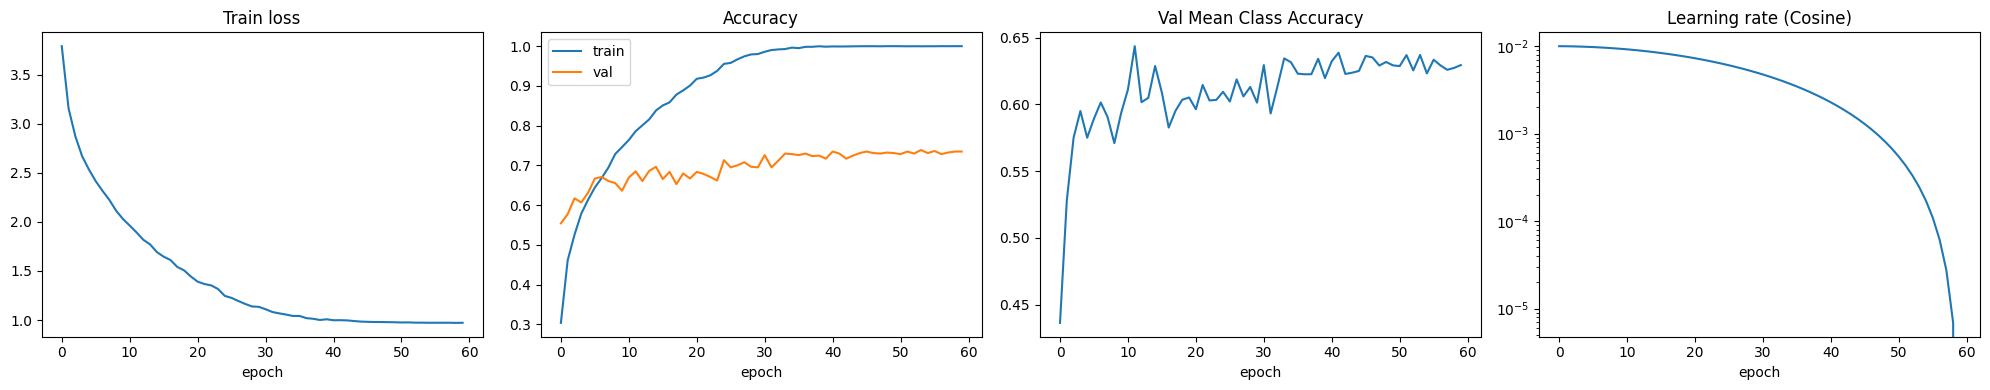

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(history["train_loss"]); axes[0].set_title("Train loss")
axes[1].plot(history["train_acc"], label="train"); axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
axes[2].plot(history["val_mca"]); axes[2].set_title("Val Mean Class Accuracy")
axes[3].plot(history["lr"]); axes[3].set_title("Learning rate (Cosine)"); axes[3].set_yscale("log")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.savefig(os.path.join(OUT_ROOT, "training_curves.png"), dpi=200)
plt.show()


---

If this beats 72.38% test_top1 while also improving test_mca and the gap over the combined_reg_cosine run, that confirms tcn_dropout really was the problem, not the cosine schedule or the other regularizers. If top1 drops back toward the StepLR-era numbers, that would suggest tcn_dropout was doing some useful work after all despite the isolated ablation - worth knowing either way, since this is now the cleanest, most evidence-backed version of the cosine approach we've built.